# COMP9444 Group Project — Fruit and Vegetable Freshness Assessment

**Task.** Binary classification of **fresh** vs **rotten** produce, following the pipeline of
Yuan & Chen (2024):

> image → frozen ImageNet-pretrained CNN (feature extractor) → PCA → classical classifier (SVM / LDA / Bagging)

**Dataset.** 12,000 images, 20 original classes (5 fruits + 5 vegetables, each *fresh* / *rotten*),
remapped to the binary target. Stratified 70 / 15 / 15 split, seed 42.

**What this notebook contains.** The complete method — split construction, feature extraction,
the PCA + classifier pipeline, the backbone / classifier comparisons, the PCA and augmentation
ablations, model selection, the single final test evaluation, and error analysis.

**How it executes.** Feature extraction requires the 12,000 raw images and a GPU, so it was run
offline; its code and its recorded run metadata are shown in Section 4. **Everything from
Section 5 onward is executed live in this notebook** from the committed feature arrays — every
number below is computed by the cell above it, not read from a stored result file.

## 1. Project objectives

1. Establish a reproducible transfer-learning baseline (ResNet-18).
2. Compare **DenseNet-201** and **ResNeXt-101** as frozen feature extractors.
3. Compare **SVM**, **LDA**, and **Bagging** on high-dimensional CNN features.
4. Measure the effect of **PCA (95% variance)** and of **training augmentation**.
5. Select the final configuration on **validation Macro-F1**, and evaluate the test set **once**.

In [1]:
%matplotlib inline
import json, sys, time, platform, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import Image, display

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "results").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "results").exists():
    raise FileNotFoundError(
        "Cannot locate the project root: expected a 'results/' directory here or one level up."
    )

RESULTS = PROJECT_ROOT / "results"
FEATURES = RESULTS / "features"
TABLES = RESULTS / "tables"
FIGURES = RESULTS / "figures"
DOCS = PROJECT_ROOT / "docs"

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.width", 160, "display.max_columns", 40, "display.precision", 4)

print("Project root :", PROJECT_ROOT)
print("Python       :", sys.version.split()[0], "|", platform.system())
print("numpy        :", np.__version__)
print("pandas       :", pd.__version__)
print("scikit-learn :", sklearn.__version__)
print("Global seed  :", SEED)

Project root : E:\桌面\UNSW26T2\COMP9444\project
Python       : 3.13.5 | Windows
numpy        : 2.1.3
pandas       : 2.2.3
scikit-learn : 1.6.1
Global seed  : 42


## 2. Dataset and the official split

The split is built **once** by `src/preprocessing/make_split.py` and shared by every experiment,
so DenseNet-201, ResNeXt-101 and ResNet-18 all see exactly the same train / val / test images.
The split is stratified on the **20 original classes** (not on the binary target), which keeps
every fruit/vegetable type proportionally represented in all three splits.

The function below is the split logic used to produce `docs/file_list.csv`.

In [2]:
from sklearn.model_selection import train_test_split


def stratified_split(frame: pd.DataFrame, seed: int = SEED) -> pd.DataFrame:
    """Stratified 70/15/15 train/val/test split over the 20 original classes.

    Two chained calls: first hold out 30%, then halve it into val and test. Stratifying on
    `label` (the 20-class name) rather than the binary target keeps produce types balanced.
    """
    train_df, holdout = train_test_split(
        frame, test_size=0.30, random_state=seed, stratify=frame["label"]
    )
    val_df, test_df = train_test_split(
        holdout, test_size=0.50, random_state=seed, stratify=holdout["label"]
    )
    out = frame.copy()
    out.loc[train_df.index, "split"] = "train"
    out.loc[val_df.index, "split"] = "val"
    out.loc[test_df.index, "split"] = "test"
    return out


def binary_label(label: str) -> str:
    """Map an original 20-class label to the binary freshness target."""
    value = label.lower().replace(" ", "").replace("_", "").replace("-", "")
    if value.startswith("fresh"):
        return "fresh"
    if value.startswith("rotten"):
        return "rotten"
    raise ValueError(f"Unknown freshness label: {label}")


print("Split rule   : 70% train / 15% val / 15% test, stratified on the 20 original classes")
print("Seed         :", SEED)
print("Recorded in  : docs/file_list.csv  (columns: filepath, label, split)")
print("Example remap:", [f"{c} -> {binary_label(c)}" for c in ("freshapple", "rottenTomato")])

Split rule   : 70% train / 15% val / 15% test, stratified on the 20 original classes
Seed         : 42
Recorded in  : docs/file_list.csv  (columns: filepath, label, split)
Example remap: ['freshapple -> fresh', 'rottenTomato -> rotten']


In [3]:
split_summary = pd.read_csv(TABLES / "split_summary.csv")
per_class = split_summary[~split_summary["label"].eq("ALL")].copy()
per_class["freshness"] = per_class["label"].map(binary_label)

print(f"Original classes: {per_class['label'].nunique()}   Images: {int(per_class['total'].sum()):,}")
display(
    per_class.groupby("freshness")[["train", "val", "test", "total"]]
    .sum()
    .assign(share=lambda d: (d["total"] / d["total"].sum()).round(4))
)
display(per_class[["label", "train", "val", "test", "total"]].head(20).reset_index(drop=True))

Original classes: 20   Images: 12,000


,train,val,test,total,share
freshness,,,,,
fresh,4276,918,917,6111,0.5092
rotten,4123,883,883,5889,0.4908


,label,train,val,test,total
0,freshapple,428,92,92,612
1,freshbanana,436,94,94,624
2,freshbellpepper,427,92,92,611
3,freshcarrot,434,93,93,620
4,freshcucumber,426,91,91,608
5,freshmango,423,91,91,605
6,freshorange,427,91,91,609
7,freshpotato,431,92,92,615
8,freshstrawberry,422,91,90,603
9,freshtomato,422,91,91,604


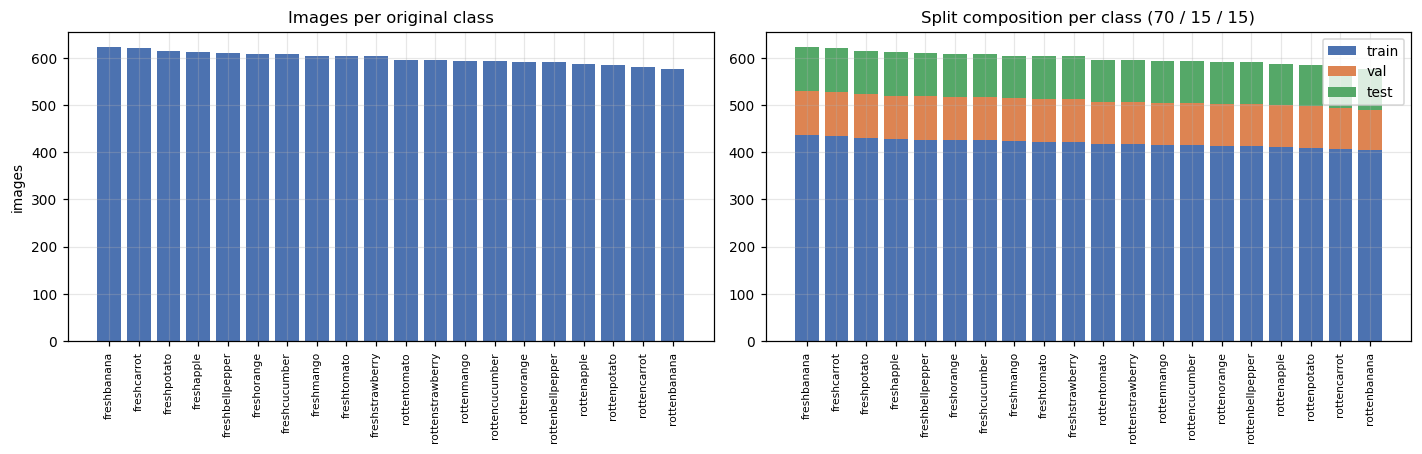

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
order = per_class.sort_values("total", ascending=False)
axes[0].bar(range(len(order)), order["total"], color="#4C72B0")
axes[0].set_xticks(range(len(order)))
axes[0].set_xticklabels(order["label"], rotation=90, fontsize=7)
axes[0].set_title("Images per original class")
axes[0].set_ylabel("images")

bottom = np.zeros(len(order))
for name, colour in zip(["train", "val", "test"], ["#4C72B0", "#DD8452", "#55A868"]):
    axes[1].bar(range(len(order)), order[name], bottom=bottom, label=name, color=colour)
    bottom += order[name].to_numpy()
axes[1].set_xticks(range(len(order)))
axes[1].set_xticklabels(order["label"], rotation=90, fontsize=7)
axes[1].set_title("Split composition per class (70 / 15 / 15)")
axes[1].legend()
plt.tight_layout()
plt.show()

## 3. Common experimental protocol

Every experiment in this notebook obeys the same contract (`docs/EXPERIMENT_RULES.md`):

| Item | Setting |
| --- | --- |
| Input | RGB, 224 × 224, ImageNet mean/std normalisation |
| Split | 70 / 15 / 15, stratified, seed 42, shared by all backbones |
| Backbones | Frozen ImageNet-pretrained — final classifier layer replaced by `Identity()` |
| Dimensionality reduction | `PCA(n_components=0.95, svd_solver="full")` |
| Classifiers | RBF SVM (C=1.0, gamma=scale) · LDA (lsqr + auto shrinkage) · Bagging (100 trees) |
| Metrics | Accuracy, macro Precision / Recall / F1, weighted F1 |
| Selection metric | **Validation** Macro-F1 |

**Leakage control.** `StandardScaler` and `PCA` are fitted on **training features only** and then
applied to validation / test features. This is enforced structurally by putting them inside a
`sklearn.pipeline.Pipeline`, so `.fit()` can never see validation or test data. The test split is
touched exactly once, in Section 9, after the configuration has already been chosen.

## 4. Feature extraction (executed offline)

One parameterised extractor covers all three backbones — they differ only in the torchvision
constructor, the weights enum, and which attribute is replaced by `Identity()`. Augmentation is
applied to the **training split only**; validation and test always use the deterministic resize.

This is the only stage that needs the raw images and a GPU, so it was run offline via
`src/feature_extraction/`. The recorded metadata for those runs is printed in the next cell.

In [5]:
# torch is only needed to *run* extraction; the code is shown here as the method of record.
try:
    import torch
    from torch.utils.data import Dataset, DataLoader
    from torchvision import models, transforms
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    Dataset = object  # shim so the class below still defines cleanly

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

BACKBONES = {
    "resnet18":     dict(ctor="resnet18",     weights="ResNet18_Weights.DEFAULT",     head="fc",         dim=512),
    "densenet201":  dict(ctor="densenet201",  weights="DenseNet201_Weights.DEFAULT",  head="classifier", dim=1920),
    "resnext101":   dict(ctor="resnext101_32x8d", weights="ResNeXt101_32X8D_Weights.DEFAULT", head="fc", dim=2048),
}


def make_transform(case: str, split: str):
    """Augmentation is applied to the training split only; val/test stay deterministic."""
    normalise = [transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]
    if case == "aug" and split == "train":
        return transforms.Compose([
            transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomRotation(10),
            transforms.ColorJitter(0.15, 0.15, 0.10, 0.03),
            *normalise,
        ])
    return transforms.Compose([transforms.Resize((224, 224)), *normalise])


class OfficialDataset(Dataset):
    """Iterates docs/file_list.csv in row order so every backbone aligns row-for-row."""

    def __init__(self, frame: pd.DataFrame, case: str, split: str):
        self.frame = frame.reset_index(drop=True)
        self.case, self.split = case, split
        self.transform = make_transform(case, split)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        from PIL import Image as PILImage
        row = self.frame.iloc[index]
        image = PILImage.open(row.filepath).convert("RGB")
        if self.case == "aug" and self.split == "train":
            # Per-index seeding makes the random augmentation reproducible.
            with torch.random.fork_rng(devices=[]):
                torch.manual_seed(SEED + index)
                tensor = self.transform(image)
        else:
            tensor = self.transform(image)
        return tensor, row.label, binary_label(row.label), row.filepath


def build_backbone(name: str, device):
    """Load an ImageNet-pretrained backbone, strip its classifier head, and freeze it."""
    spec = BACKBONES[name]
    weights = eval(f"models.{spec['weights']}")
    model = getattr(models, spec["ctor"])(weights=weights)
    setattr(model, spec["head"], torch.nn.Identity())   # -> penultimate embedding
    for parameter in model.parameters():
        parameter.requires_grad = False                 # frozen: no fine-tuning
    return model.eval().to(device)


def extract_features(model, frame, case, split, device, batch_size=32):
    """Run one forward pass over a split and return (features, 20-class labels, binary labels)."""
    loader = DataLoader(OfficialDataset(frame, case, split), batch_size=batch_size, shuffle=False)
    feats, labels, binaries = [], [], []
    with torch.no_grad():                               # frozen: no gradients needed
        for images, label, binary, _ in loader:
            feats.append(model(images.to(device)).cpu().numpy())
            labels.extend(label)
            binaries.extend(binary)
    return np.concatenate(feats), np.asarray(labels), np.asarray(binaries)


print("torch available in this kernel:", TORCH_AVAILABLE)
print("Backbones:")
for name, spec in BACKBONES.items():
    print(f"  {name:<12} {spec['weights']:<38} head={spec['head']:<10} feature_dim={spec['dim']}")

torch available in this kernel: False
Backbones:
  resnet18     ResNet18_Weights.DEFAULT               head=fc         feature_dim=512
  densenet201  DenseNet201_Weights.DEFAULT            head=classifier feature_dim=1920
  resnext101   ResNeXt101_32X8D_Weights.DEFAULT       head=fc         feature_dim=2048


In [6]:
# Metadata recorded by the offline extraction runs.
for label, path in [
    ("ResNet-18  (no_aug)", FEATURES / "resnet18_baseline/metadata.json"),
    ("DenseNet-201 (no_aug)", FEATURES / "no_aug/metadata.json"),
    ("DenseNet-201 (aug)", FEATURES / "aug/metadata.json"),
]:
    meta = json.loads(path.read_text())
    rows = {k: v.get("rows", v.get("reused_from")) for k, v in meta["splits"].items()}
    print(f"{label:<22} dim={meta['feature_dim']:<5} seed={meta['seed']}  splits={rows}")

# Shape check: every stored feature array, and its alignment with the split sizes.
print("\nStored feature arrays")
checks = {
    "resnet18   train/val": [FEATURES / f"resnet18_baseline/resnet18_{s}_features.npy" for s in ("train", "val")],
    "densenet no_aug      ": [FEATURES / f"no_aug/densenet201_{s}_features.npy" for s in ("train", "val", "test")],
    "densenet aug         ": [FEATURES / f"aug/densenet201_{s}_features.npy" for s in ("train", "val", "test")],
    "resnext  no_aug/aug  ": [FEATURES / "resnext101_features.npy", FEATURES / "resnext101_aug_features.npy"],
}
for name, paths in checks.items():
    shapes = [np.load(p, mmap_mode="r").shape for p in paths]
    print(f"  {name} {shapes}")

ResNet-18  (no_aug)    dim=512   seed=42  splits={'train': 8399, 'val': 1801}
DenseNet-201 (no_aug)  dim=1920  seed=42  splits={'train': 8399, 'val': 1801, 'test': 1800}
DenseNet-201 (aug)     dim=1920  seed=42  splits={'train': 8399, 'val': 1801, 'test': 1800}

Stored feature arrays
  resnet18   train/val [(8399, 512), (1801, 512)]
  densenet no_aug       [(8399, 1920), (1801, 1920), (1800, 1920)]
  densenet aug          [(8399, 1920), (1801, 1920), (1800, 1920)]
  resnext  no_aug/aug   [(12000, 2048), (12000, 2048)]


## 5. The PCA + classifier pipeline

This is the core of the method and the code every experiment below calls. `Pipeline` guarantees
the leakage rule: `StandardScaler` and `PCA` learn their parameters inside `fit()` on training
features only, and are merely *applied* to the evaluation split.

In [7]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             precision_recall_fscore_support)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

CLASSES = np.asarray(["fresh", "rotten"])


def make_classifier(name: str):
    """The three classical classifiers, with the settings fixed for the whole study."""
    if name == "svm":
        return SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEED)
    if name == "lda":
        return LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
    if name == "bagging":
        return BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=SEED),
            n_estimators=100, random_state=SEED, n_jobs=-1,
        )
    raise ValueError(f"Unknown classifier: {name}")


def build_pipeline(classifier_name: str, use_pca: bool) -> Pipeline:
    steps = [("scaler", StandardScaler())]
    if use_pca:
        steps.append(("pca", PCA(n_components=0.95, svd_solver="full", random_state=SEED)))
    steps.append(("clf", make_classifier(classifier_name)))
    return Pipeline(steps)


# ---- feature loaders -------------------------------------------------------
def load_densenet(case: str) -> dict:
    """case: 'no_aug' | 'aug'. Returns {split: (X, y_binary)}."""
    root = FEATURES / case
    return {
        split: (np.load(root / f"densenet201_{split}_features.npy"),
                np.load(root / f"densenet201_{split}_binary_labels.npy"))
        for split in ("train", "val", "test")
    }


def load_resnext(case: str) -> dict:
    """ResNeXt features are stored flat with a parallel split array; slice them back apart."""
    suffix = "_aug" if case == "aug" else ""
    X = np.load(FEATURES / f"resnext101{suffix}_features.npy")
    y = np.asarray([binary_label(v) for v in np.load(FEATURES / f"resnext101{suffix}_labels.npy")])
    splits = np.load(FEATURES / f"resnext101{suffix}_splits.npy")
    return {s: (X[splits == s], y[splits == s]) for s in ("train", "val", "test")}


def load_resnet18() -> dict:
    root = FEATURES / "resnet18_baseline"
    return {
        split: (np.load(root / f"resnet18_{split}_features.npy"),
                np.load(root / f"resnet18_{split}_binary_labels.npy"))
        for split in ("train", "val")   # test intentionally not loaded at baseline stage
    }


# ---- one experiment --------------------------------------------------------
RUNS = []          # every experiment executed in this notebook is appended here
PREDICTIONS = {}   # run_id -> (y_true, y_pred) for later error analysis


def run_experiment(run_id, data, backbone, feature_case, classifier_name, use_pca,
                   target="val", verbose=True):
    """Fit on train, predict one target split, record metrics. Returns the metric row."""
    X_train, y_train = data["train"]
    X_eval, y_eval = data[target]

    model = build_pipeline(classifier_name, use_pca)
    started = time.perf_counter()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_eval)
    elapsed = time.perf_counter() - started

    macro = precision_recall_fscore_support(y_eval, y_pred, labels=CLASSES,
                                            average="macro", zero_division=0)
    weighted = precision_recall_fscore_support(y_eval, y_pred, labels=CLASSES,
                                               average="weighted", zero_division=0)
    row = {
        "run_id": run_id, "backbone": backbone, "feature_case": feature_case,
        "classifier": classifier_name.upper(), "pca": "PCA(95%)" if use_pca else "none",
        "split": target,
        "accuracy": accuracy_score(y_eval, y_pred),
        "macro_precision": macro[0], "macro_recall": macro[1], "macro_f1": macro[2],
        "weighted_f1": weighted[2],
        "raw_dim": X_train.shape[1],
        "pca_dim": int(model.named_steps["pca"].n_components_) if use_pca else None,
        "seconds": elapsed,
    }
    RUNS.append(row)
    PREDICTIONS[run_id] = (y_eval, y_pred)
    if verbose:
        print(f"{run_id:<34} {target:<5} acc={row['accuracy']:.4f}  macroF1={row['macro_f1']:.4f}  "
              f"dim={row['raw_dim']}->{row['pca_dim'] or row['raw_dim']}  {elapsed:6.1f}s")
    return row


def plot_confusion(run_id, ax=None, title=None):
    y_true, y_pred = PREDICTIONS[run_id]
    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    ax = ax or plt.subplots(figsize=(3.6, 3.2))[1]
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1], CLASSES); ax.set_yticks([0, 1], CLASSES)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(title or run_id, fontsize=9)
    ax.grid(False)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", fontsize=11,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    return cm


print("Pipeline for DenseNet + PCA + SVM:")
print(build_pipeline("svm", use_pca=True))

Pipeline for DenseNet + PCA + SVM:
Pipeline(steps=[('scaler', StandardScaler()),
                ('pca',
                 PCA(n_components=0.95, random_state=42, svd_solver='full')),
                ('clf', SVC(random_state=42))])


## 6. ResNet-18 baseline

A deliberately lightweight reference point: frozen ResNet-18 (512-d) → StandardScaler →
PCA(95%) → RBF SVM, no augmentation. Test features are not loaded at this stage.

In [8]:
resnet18_data = load_resnet18()
print("ResNet-18 features:", {k: v[0].shape for k, v in resnet18_data.items()}, "\n")

baseline = run_experiment("resnet18_baseline_svm_pca", resnet18_data,
                          "ResNet-18", "no_aug", "svm", use_pca=True)

display(pd.DataFrame([baseline])[["accuracy", "macro_precision", "macro_recall",
                                  "macro_f1", "weighted_f1", "raw_dim", "pca_dim", "seconds"]])

ResNet-18 features: {'train': (8399, 512), 'val': (1801, 512)} 



resnet18_baseline_svm_pca          val   acc=0.9761  macroF1=0.9761  dim=512->245     4.2s


,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,raw_dim,pca_dim,seconds
0,0.9761,0.9762,0.9761,0.9761,0.9761,512,245,4.1576


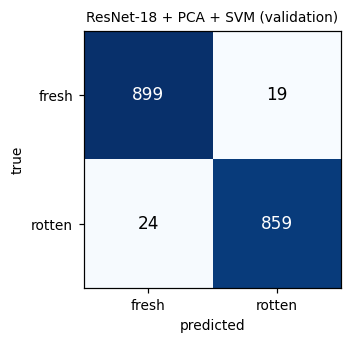

              precision    recall  f1-score   support

       fresh     0.9740    0.9793    0.9766       918
      rotten     0.9784    0.9728    0.9756       883

    accuracy                         0.9761      1801
   macro avg     0.9762    0.9761    0.9761      1801
weighted avg     0.9761    0.9761    0.9761      1801



In [9]:
fig, ax = plt.subplots(figsize=(3.6, 3.2))
plot_confusion("resnet18_baseline_svm_pca", ax, "ResNet-18 + PCA + SVM (validation)")
plt.tight_layout(); plt.show()

y_true, y_pred = PREDICTIONS["resnet18_baseline_svm_pca"]
print(classification_report(y_true, y_pred, labels=CLASSES, target_names=CLASSES, digits=4))

## 7. Backbone comparison — DenseNet-201 vs ResNeXt-101

Controlled comparison: identical split, identical augmented feature case, identical SVM, run both
with and without PCA. The only thing that varies is the backbone.

In [10]:
densenet_aug = load_densenet("aug")
resnext_aug = load_resnext("aug")

print("DenseNet-201 (aug):", {k: v[0].shape for k, v in densenet_aug.items()})
print("ResNeXt-101  (aug):", {k: v[0].shape for k, v in resnext_aug.items()}, "\n")

for backbone, data, key in [("DenseNet-201", densenet_aug, "densenet"),
                            ("ResNeXt-101", resnext_aug, "resnext")]:
    for use_pca in (False, True):
        run_experiment(f"{key}_aug_svm_{'pca' if use_pca else 'nopca'}",
                       data, backbone, "aug", "svm", use_pca)

backbone_table = pd.DataFrame(RUNS)
backbone_table = backbone_table[backbone_table["run_id"].str.contains("_aug_svm_")]
display(backbone_table[["backbone", "pca", "accuracy", "macro_f1", "weighted_f1",
                        "raw_dim", "pca_dim", "seconds"]].reset_index(drop=True))

DenseNet-201 (aug): {'train': (8399, 1920), 'val': (1801, 1920), 'test': (1800, 1920)}
ResNeXt-101  (aug): {'train': (8399, 2048), 'val': (1801, 2048), 'test': (1800, 2048)} 



densenet_aug_svm_nopca             val   acc=0.9783  macroF1=0.9783  dim=1920->1920    24.9s


densenet_aug_svm_pca               val   acc=0.9772  macroF1=0.9772  dim=1920->738    11.1s


resnext_aug_svm_nopca              val   acc=0.9495  macroF1=0.9494  dim=2048->2048    37.6s


resnext_aug_svm_pca                val   acc=0.9528  macroF1=0.9528  dim=2048->1316    23.6s


,backbone,pca,accuracy,macro_f1,weighted_f1,raw_dim,pca_dim,seconds
0,DenseNet-201,none,0.9783,0.9783,0.9783,1920,NaN,24.8718
1,DenseNet-201,PCA(95%),0.9772,0.9772,0.9772,1920,738.0,11.0994
2,ResNeXt-101,none,0.9495,0.9494,0.9495,2048,NaN,37.5864
3,ResNeXt-101,PCA(95%),0.9528,0.9528,0.9528,2048,1316.0,23.5984


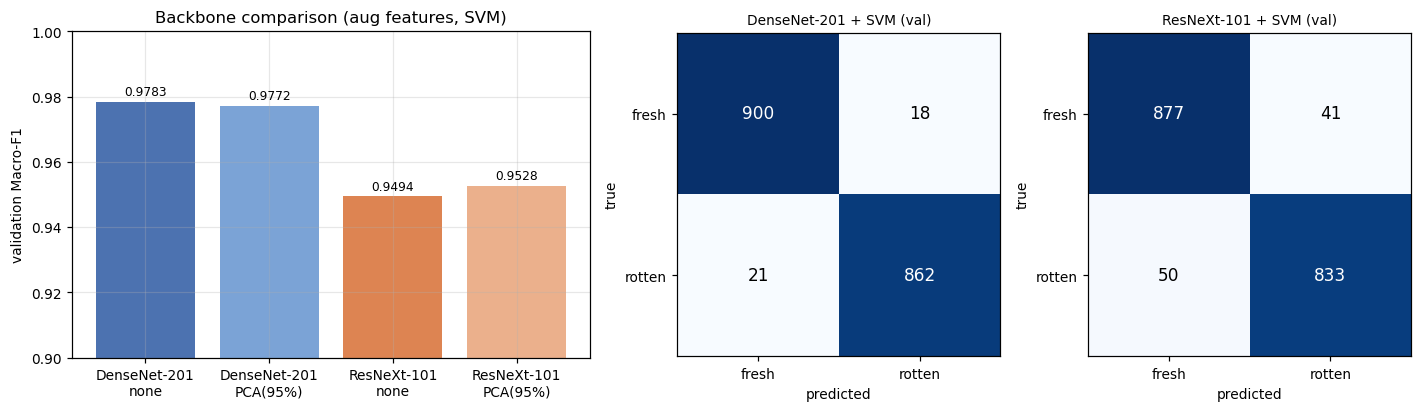

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), width_ratios=[1.6, 1, 1])

labels = [f"{r.backbone}\n{r.pca}" for r in backbone_table.itertuples()]
bars = axes[0].bar(labels, backbone_table["macro_f1"],
                   color=["#4C72B0", "#7BA3D6", "#DD8452", "#EBB08C"])
axes[0].set_ylim(0.90, 1.0); axes[0].set_ylabel("validation Macro-F1")
axes[0].set_title("Backbone comparison (aug features, SVM)")
for bar, value in zip(bars, backbone_table["macro_f1"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, value + 0.002, f"{value:.4f}",
                 ha="center", fontsize=8)

plot_confusion("densenet_aug_svm_nopca", axes[1], "DenseNet-201 + SVM (val)")
plot_confusion("resnext_aug_svm_nopca", axes[2], "ResNeXt-101 + SVM (val)")
plt.tight_layout(); plt.show()

## 8. Classifier comparison — SVM vs LDA vs Bagging

Same DenseNet-201 augmented features for all three, no PCA, so the classifier is the only
variable. Runtime is reported alongside accuracy because it differs by an order of magnitude.

In [12]:
for classifier_name in ("svm", "lda", "bagging"):
    run_id = f"densenet_aug_{classifier_name}_nopca"
    if run_id not in PREDICTIONS:
        run_experiment(run_id, densenet_aug, "DenseNet-201", "aug", classifier_name, use_pca=False)

clf_table = pd.DataFrame(RUNS)
clf_table = clf_table[clf_table["run_id"].isin(
    [f"densenet_aug_{c}_nopca" for c in ("svm", "lda", "bagging")])]
clf_table = clf_table.sort_values("macro_f1", ascending=False)
display(clf_table[["classifier", "accuracy", "macro_precision", "macro_recall",
                   "macro_f1", "seconds"]].reset_index(drop=True))

densenet_aug_lda_nopca             val   acc=0.9772  macroF1=0.9772  dim=1920->1920     2.3s


densenet_aug_bagging_nopca         val   acc=0.9406  macroF1=0.9405  dim=1920->1920   298.2s


,classifier,accuracy,macro_precision,macro_recall,macro_f1,seconds
0,SVM,0.9783,0.9784,0.9783,0.9783,24.8718
1,LDA,0.9772,0.9776,0.9770,0.9772,2.3447
2,BAGGING,0.9406,0.9413,0.9402,0.9405,298.2220


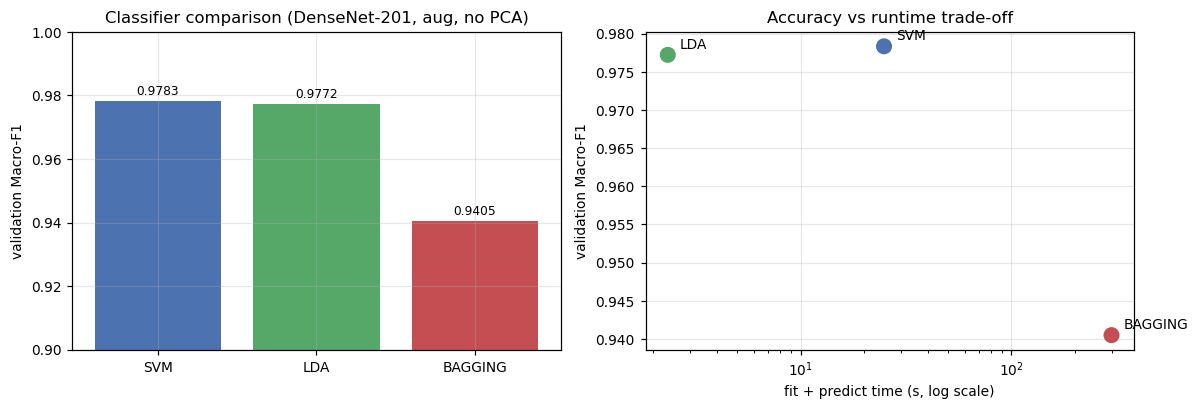

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

bars = axes[0].bar(clf_table["classifier"], clf_table["macro_f1"],
                   color=["#4C72B0", "#55A868", "#C44E52"])
axes[0].set_ylim(0.90, 1.0); axes[0].set_ylabel("validation Macro-F1")
axes[0].set_title("Classifier comparison (DenseNet-201, aug, no PCA)")
for bar, value in zip(bars, clf_table["macro_f1"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, value + 0.002, f"{value:.4f}",
                 ha="center", fontsize=8)

axes[1].scatter(clf_table["seconds"], clf_table["macro_f1"], s=90,
                c=["#4C72B0", "#55A868", "#C44E52"], zorder=3)
for row in clf_table.itertuples():
    axes[1].annotate(row.classifier, (row.seconds, row.macro_f1),
                     textcoords="offset points", xytext=(8, 4), fontsize=9)
axes[1].set_xscale("log"); axes[1].set_xlabel("fit + predict time (s, log scale)")
axes[1].set_ylabel("validation Macro-F1")
axes[1].set_title("Accuracy vs runtime trade-off")
plt.tight_layout(); plt.show()

## 9. Ablations — PCA and training augmentation

Two questions the paper's pipeline assumes an answer to, tested here rather than assumed:

1. **Does PCA(95%) help?** It always cuts dimensionality and runtime, but does it cost accuracy?
2. **Does training augmentation help?** The dataset is already fairly clean and balanced.

In [14]:
# --- Ablation 1: PCA vs no PCA, both backbones, all three classifiers -------
for backbone, data, key in [("DenseNet-201", densenet_aug, "densenet"),
                            ("ResNeXt-101", resnext_aug, "resnext")]:
    for classifier_name in ("svm", "lda", "bagging"):
        for use_pca in (False, True):
            run_id = f"{key}_aug_{classifier_name}_{'pca' if use_pca else 'nopca'}"
            if run_id not in PREDICTIONS:
                run_experiment(run_id, data, backbone, "aug", classifier_name, use_pca,
                               verbose=False)

runs = pd.DataFrame(RUNS)
ablation = runs[runs["feature_case"].eq("aug") & runs["split"].eq("val")]
pca_effect = ablation.pivot_table(index=["backbone", "classifier"], columns="pca",
                                  values="macro_f1", aggfunc="first")
pca_effect["change"] = pca_effect["PCA(95%)"] - pca_effect["none"]
pca_effect["effect"] = np.where(pca_effect["change"] > 0, "improved", "decreased")
display(pca_effect.round(4))

dims = ablation[ablation["pca"].eq("PCA(95%)")][["backbone", "raw_dim", "pca_dim"]].drop_duplicates()
print("\nDimensionality retained at 95% variance:")
for row in dims.itertuples():
    print(f"  {row.backbone:<14} {row.raw_dim} -> {row.pca_dim}  "
          f"({row.pca_dim / row.raw_dim:.1%} of the original dimensions)")

pca                      PCA(95%)    none  change     effect
backbone     classifier                                     
DenseNet-201 BAGGING       0.9149  0.9405 -0.0256  decreased
             LDA           0.9644  0.9772 -0.0128  decreased
             SVM           0.9772  0.9783 -0.0011  decreased
ResNeXt-101  BAGGING       0.8955  0.9272 -0.0317  decreased
             LDA           0.9310  0.9393 -0.0084  decreased
             SVM           0.9528  0.9494  0.0033   improved


Dimensionality retained at 95% variance:
  DenseNet-201   1920 -> 738.0  (38.4% of the original dimensions)
  ResNeXt-101    2048 -> 1316.0  (64.3% of the original dimensions)


In [15]:
# --- Ablation 2: training augmentation on / off (DenseNet-201, PCA(95%)) ----
densenet_no_aug = load_densenet("no_aug")

for classifier_name in ("svm", "lda", "bagging"):
    run_experiment(f"densenet_no_aug_{classifier_name}_pca", densenet_no_aug,
                   "DenseNet-201", "no_aug", classifier_name, use_pca=True, verbose=False)

runs = pd.DataFrame(RUNS)
aug_effect = runs[runs["backbone"].eq("DenseNet-201") & runs["pca"].eq("PCA(95%)")
                  & runs["split"].eq("val")]
aug_effect = aug_effect.pivot_table(index="classifier", columns="feature_case",
                                    values="macro_f1", aggfunc="first")
aug_effect["change"] = aug_effect["aug"] - aug_effect["no_aug"]
display(aug_effect.round(4))
print("Positive `change` would mean augmentation helps.")

feature_case,aug,no_aug,change
classifier,,,
BAGGING,0.9149,0.9445,-0.0295
LDA,0.9644,0.9661,-0.0017
SVM,0.9772,0.9878,-0.0106


Positive `change` would mean augmentation helps.


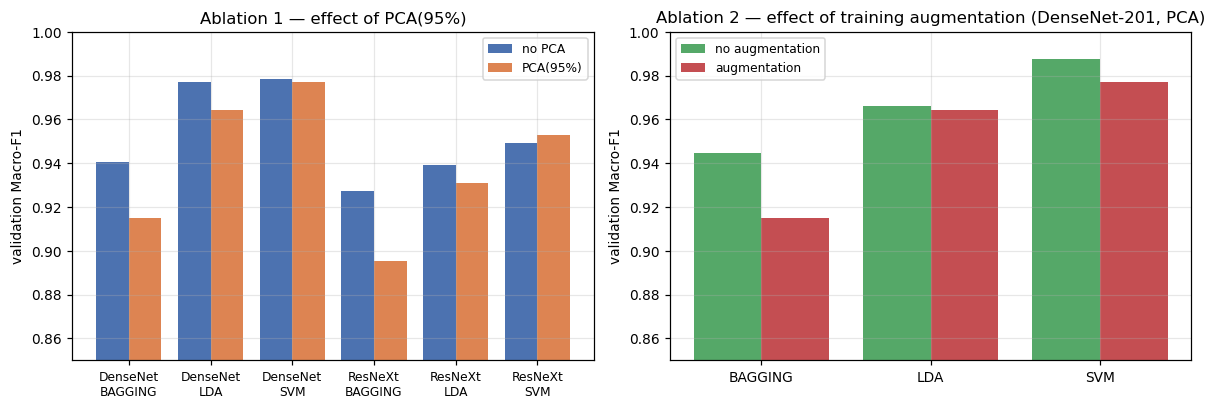

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

x = np.arange(len(pca_effect))
axes[0].bar(x - 0.2, pca_effect["none"], 0.4, label="no PCA", color="#4C72B0")
axes[0].bar(x + 0.2, pca_effect["PCA(95%)"], 0.4, label="PCA(95%)", color="#DD8452")
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{b.split('-')[0]}\n{c}" for b, c in pca_effect.index], fontsize=8)
axes[0].set_ylim(0.85, 1.0); axes[0].set_ylabel("validation Macro-F1")
axes[0].set_title("Ablation 1 — effect of PCA(95%)"); axes[0].legend(fontsize=8)

x = np.arange(len(aug_effect))
axes[1].bar(x - 0.2, aug_effect["no_aug"], 0.4, label="no augmentation", color="#55A868")
axes[1].bar(x + 0.2, aug_effect["aug"], 0.4, label="augmentation", color="#C44E52")
axes[1].set_xticks(x); axes[1].set_xticklabels(aug_effect.index)
axes[1].set_ylim(0.85, 1.0); axes[1].set_ylabel("validation Macro-F1")
axes[1].set_title("Ablation 2 — effect of training augmentation (DenseNet-201, PCA)")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 10. Model selection and the single final test evaluation

Every experiment above ran on **validation** only. The full validation leaderboard is ranked
below, the top configuration is read off it, and only then is the test split loaded and scored —
**once**. No result on this page feeds back into any choice made above it.

In [17]:
leaderboard = (pd.DataFrame(RUNS)
               .query("split == 'val'")
               .sort_values("macro_f1", ascending=False)
               .reset_index(drop=True))
leaderboard.index += 1
display(leaderboard[["backbone", "feature_case", "classifier", "pca",
                     "accuracy", "macro_f1", "weighted_f1", "seconds"]].head(12))

best = leaderboard.iloc[0]
print(f"\nSelected on validation Macro-F1: {best.backbone} | {best.feature_case} | "
      f"{best.classifier} | {best.pca}  ->  val Macro-F1 {best.macro_f1:.4f}")

,backbone,feature_case,classifier,pca,accuracy,macro_f1,weighted_f1,seconds
1,DenseNet-201,no_aug,SVM,PCA(95%),0.9878,0.9878,0.9878,10.5513
2,DenseNet-201,aug,SVM,none,0.9783,0.9783,0.9783,24.8718
3,DenseNet-201,aug,SVM,PCA(95%),0.9772,0.9772,0.9772,11.0994
4,DenseNet-201,aug,LDA,none,0.9772,0.9772,0.9772,2.3447
5,ResNet-18,no_aug,SVM,PCA(95%),0.9761,0.9761,0.9761,4.1576
6,DenseNet-201,no_aug,LDA,PCA(95%),0.9661,0.9661,0.9661,2.3146
7,DenseNet-201,aug,LDA,PCA(95%),0.9645,0.9644,0.9644,2.3423
8,ResNeXt-101,aug,SVM,PCA(95%),0.9528,0.9528,0.9528,23.5984
9,ResNeXt-101,aug,SVM,none,0.9495,0.9494,0.9495,37.5864
10,DenseNet-201,no_aug,BAGGING,PCA(95%),0.9445,0.9445,0.9445,98.7191



Selected on validation Macro-F1: DenseNet-201 | no_aug | SVM | PCA(95%)  ->  val Macro-F1 0.9878


In [18]:
# ---- the one and only test-set evaluation ---------------------------------
final_data = load_densenet("no_aug")
print("Test split loaded for the first time:", final_data["test"][0].shape, "\n")

final = run_experiment("FINAL_densenet_no_aug_svm_pca95", final_data,
                       "DenseNet-201", "no_aug", "svm", use_pca=True, target="test")

display(pd.DataFrame([final])[["backbone", "feature_case", "classifier", "pca", "split",
                               "accuracy", "macro_precision", "macro_recall", "macro_f1",
                               "weighted_f1", "raw_dim", "pca_dim"]])

Test split loaded for the first time: (1800, 1920) 



FINAL_densenet_no_aug_svm_pca95    test  acc=0.9828  macroF1=0.9828  dim=1920->690    10.2s


,backbone,feature_case,classifier,pca,split,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,raw_dim,pca_dim
0,DenseNet-201,no_aug,SVM,PCA(95%),test,0.9828,0.9829,0.9827,0.9828,0.9828,1920,690


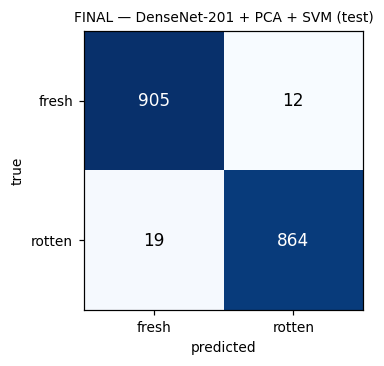

              precision    recall  f1-score   support

       fresh     0.9794    0.9869    0.9832       917
      rotten     0.9863    0.9785    0.9824       883

    accuracy                         0.9828      1800
   macro avg     0.9829    0.9827    0.9828      1800
weighted avg     0.9828    0.9828    0.9828      1800

Test errors: 31 of 1800 images (1.72%)


In [19]:
fig, ax = plt.subplots(figsize=(3.8, 3.4))
cm = plot_confusion("FINAL_densenet_no_aug_svm_pca95", ax,
                    "FINAL — DenseNet-201 + PCA + SVM (test)")
plt.tight_layout(); plt.show()

y_true, y_pred = PREDICTIONS["FINAL_densenet_no_aug_svm_pca95"]
print(classification_report(y_true, y_pred, labels=CLASSES, target_names=CLASSES, digits=4))
print(f"Test errors: {(y_true != y_pred).sum()} of {len(y_true)} images "
      f"({(y_true != y_pred).mean():.2%})")

## 11. Error analysis

Where does the selected model actually fail, and is the failure mode symmetric?

In [20]:
y_true, y_pred = PREDICTIONS["FINAL_densenet_no_aug_svm_pca95"]
wrong = y_true != y_pred

error_breakdown = pd.DataFrame({
    "true": y_true[wrong], "predicted": y_pred[wrong]
}).value_counts().rename("count").reset_index()
error_breakdown["share_of_class"] = [
    row["count"] / (y_true == row["true"]).sum() for _, row in error_breakdown.iterrows()
]
display(error_breakdown)

print("Per-class recall on the test split:")
for cls in CLASSES:
    mask = y_true == cls
    print(f"  {cls:<7} {(y_pred[mask] == cls).sum():>4}/{mask.sum():<5} = {(y_pred[mask] == cls).mean():.4f}")

,true,predicted,count,share_of_class
0,rotten,fresh,19,0.0215
1,fresh,rotten,12,0.0131


Per-class recall on the test split:
  fresh    905/917   = 0.9869
  rotten   864/883   = 0.9785


Hardest validation errors — DenseNet-201 + PCA + SVM


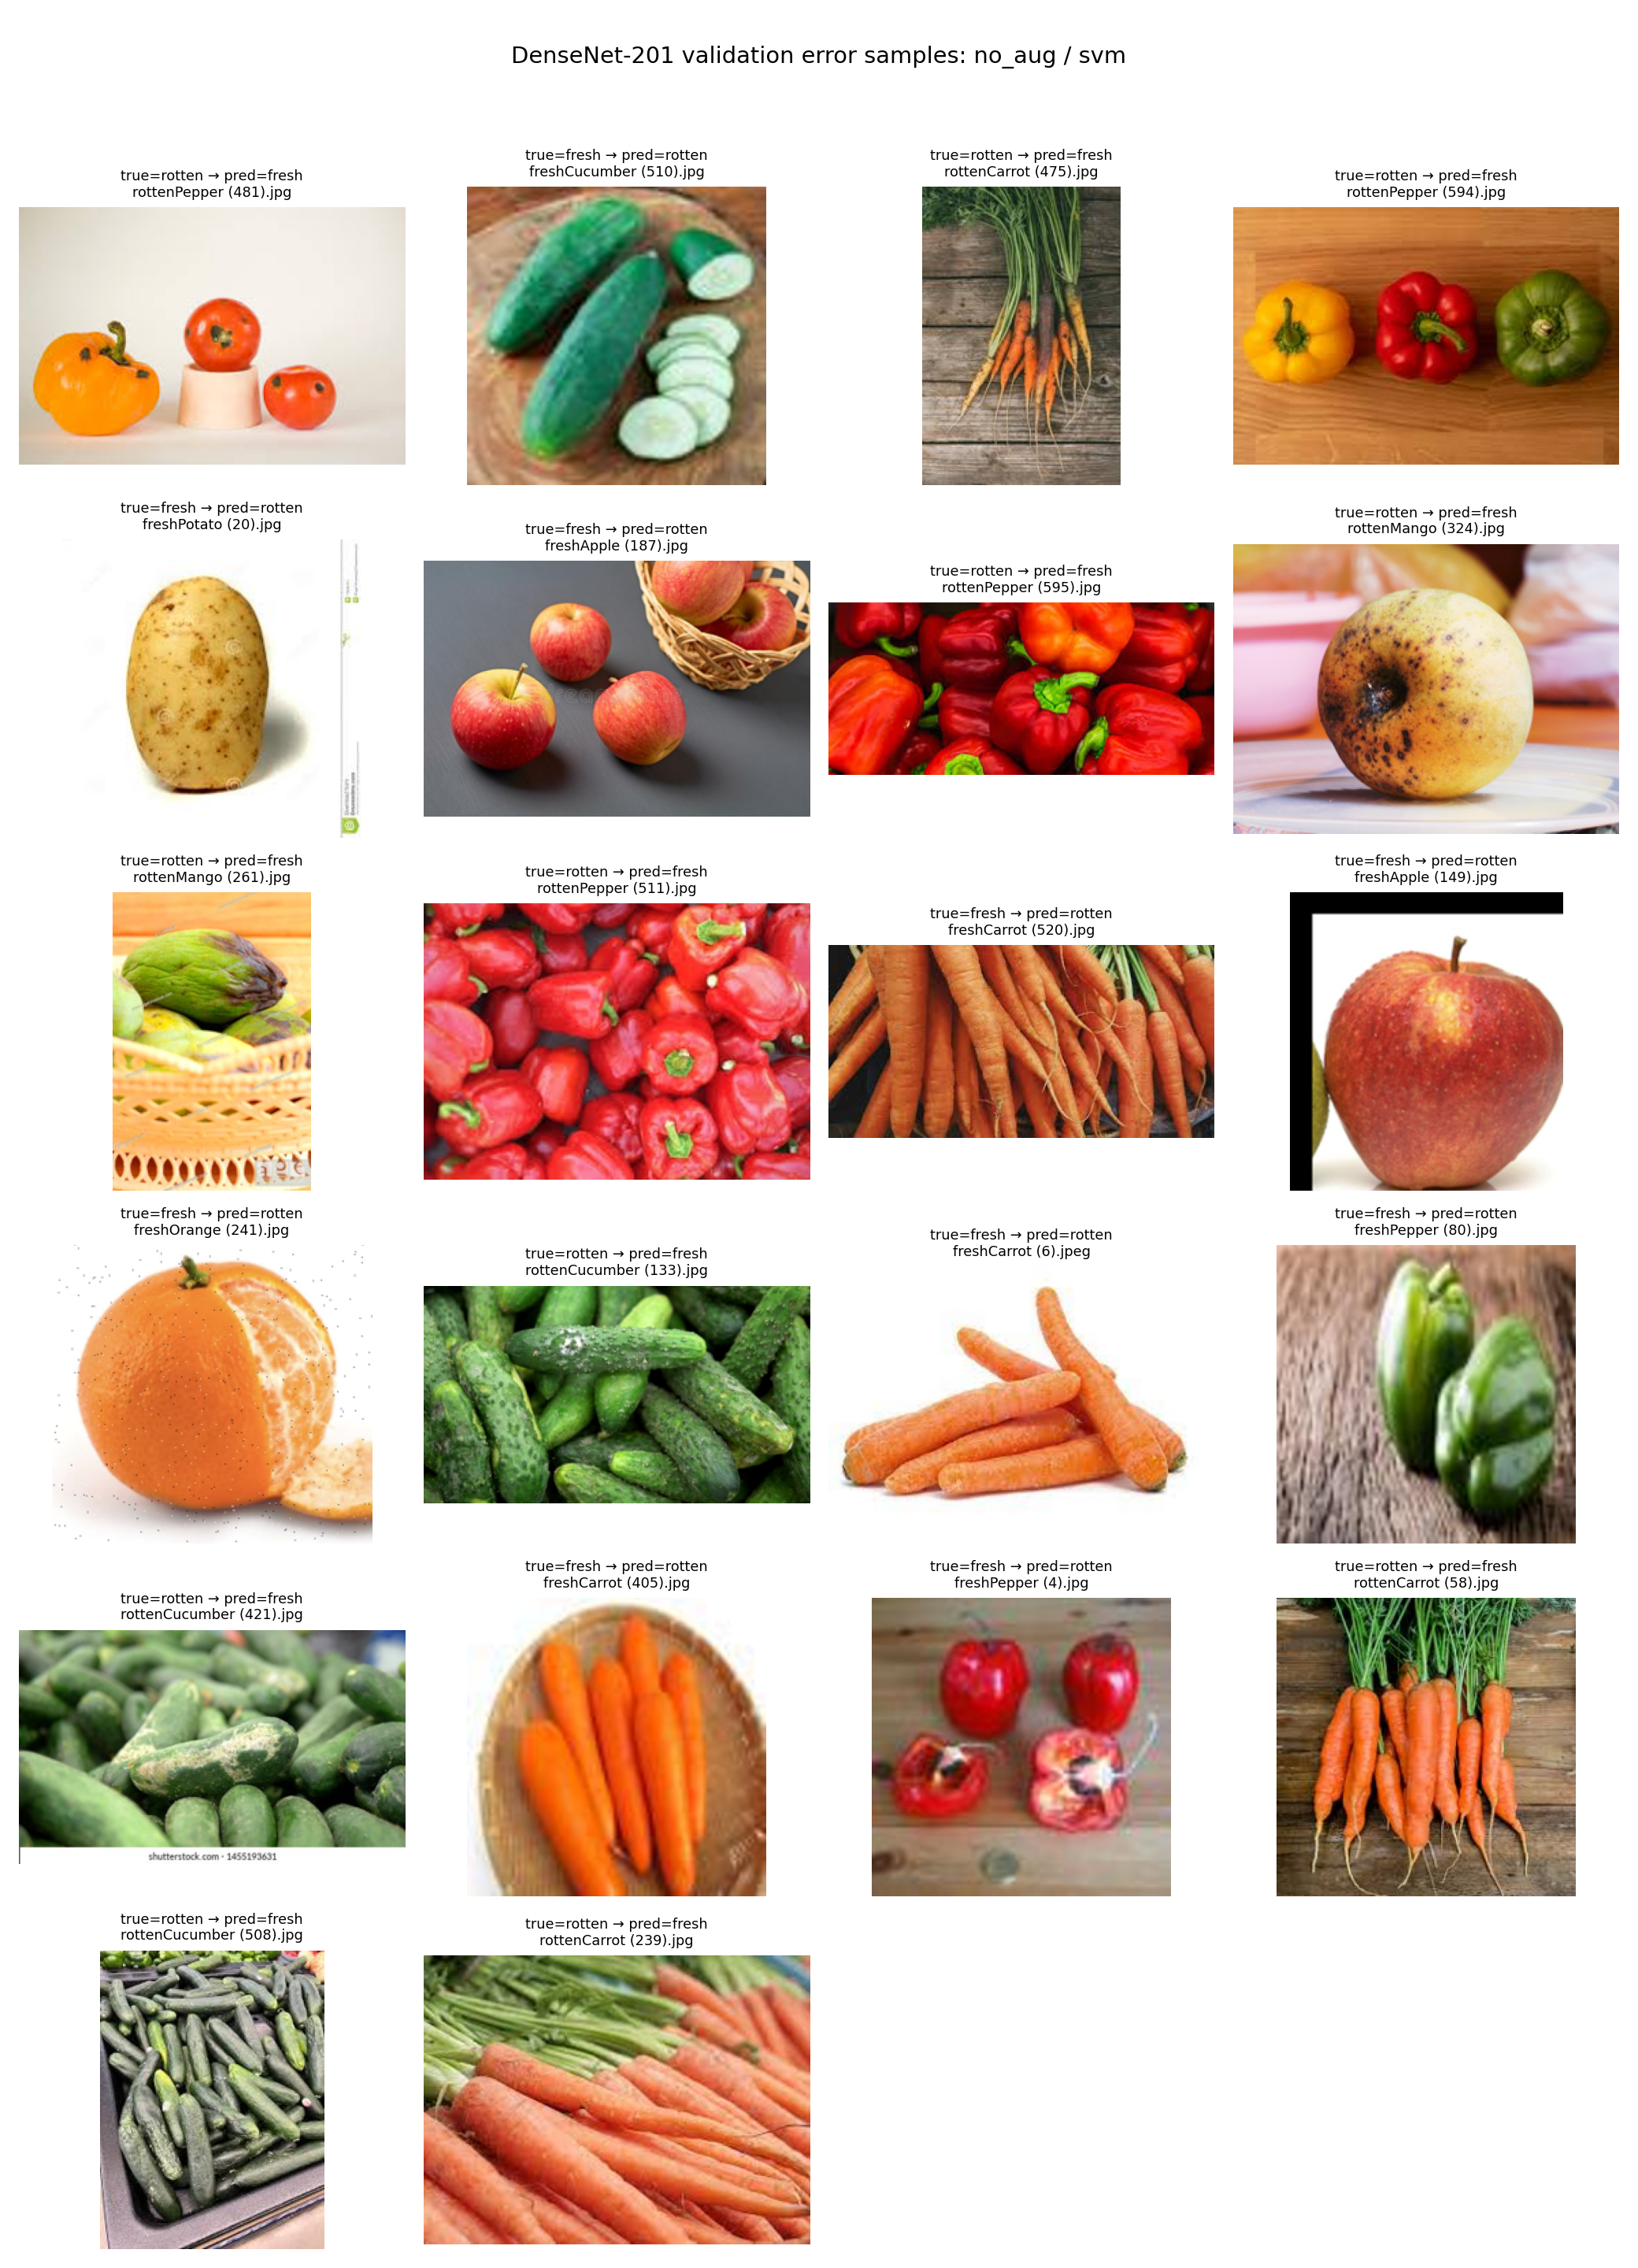

In [21]:
# Misclassified validation images from the same configuration, rendered offline.
grid = FIGURES / "error_samples/densenet201_no_aug_svm_error_samples_val.png"
if grid.exists():
    print("Hardest validation errors — DenseNet-201 + PCA + SVM")
    display(Image(filename=str(grid)))

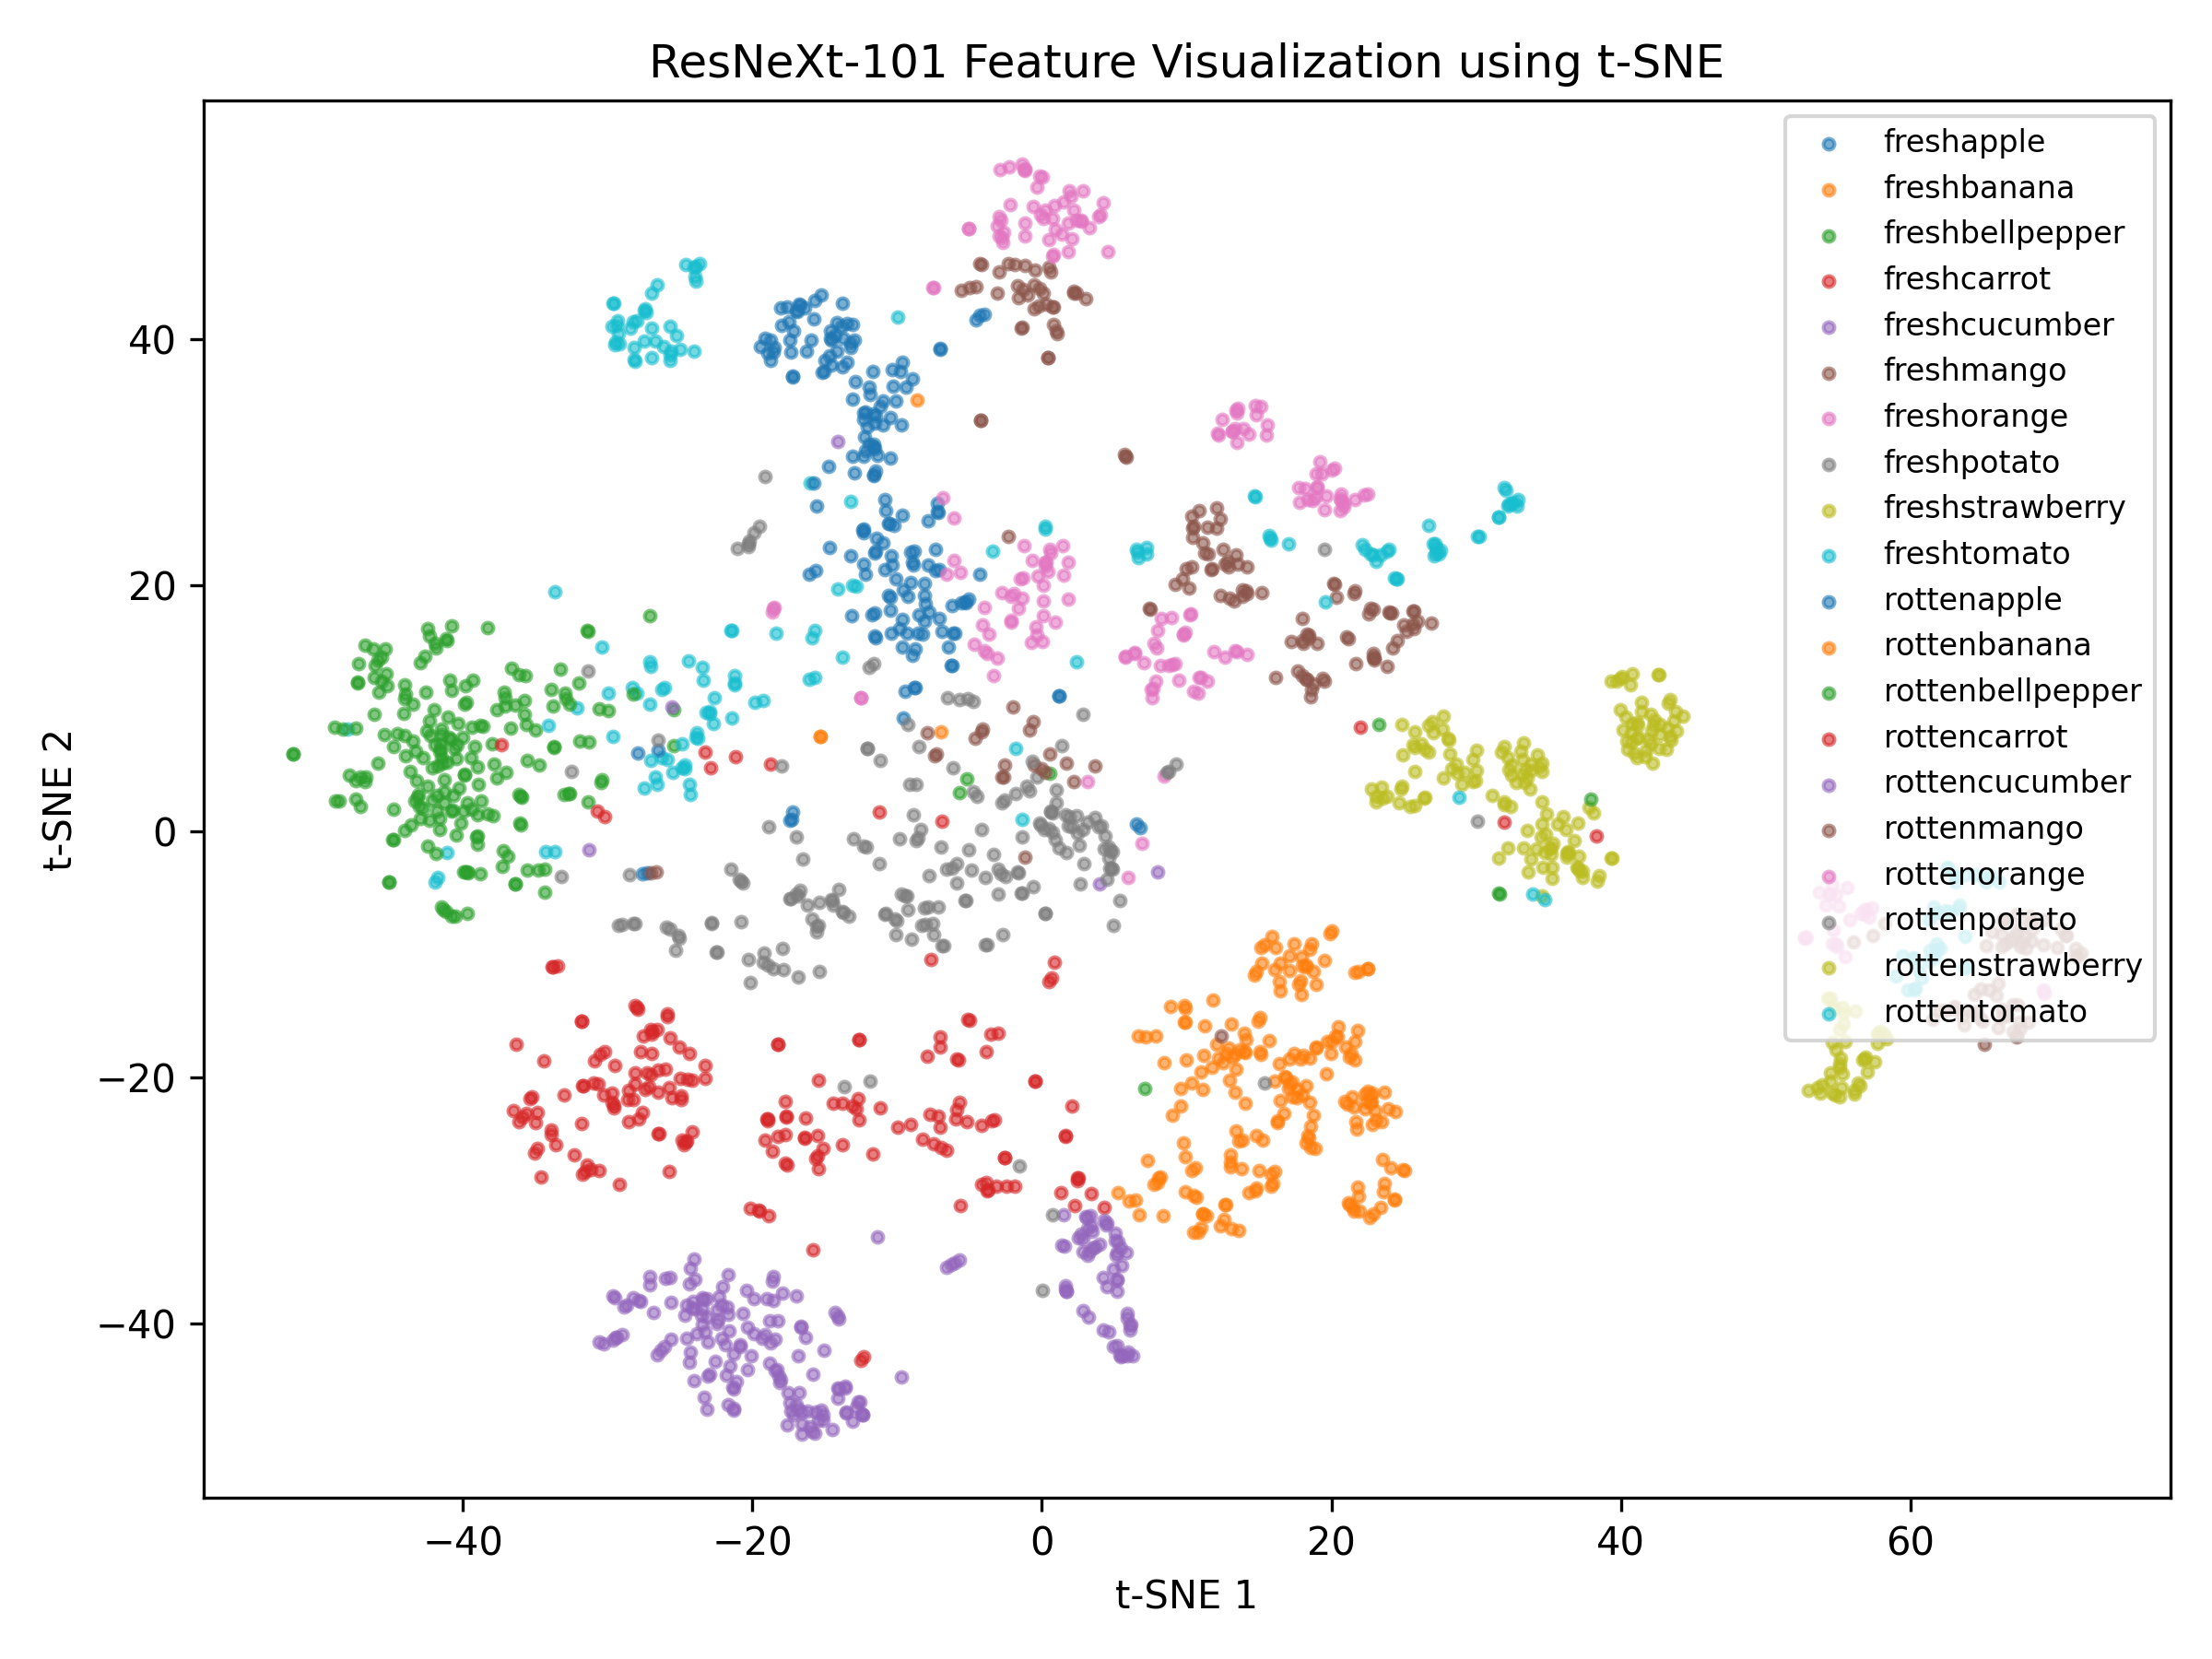

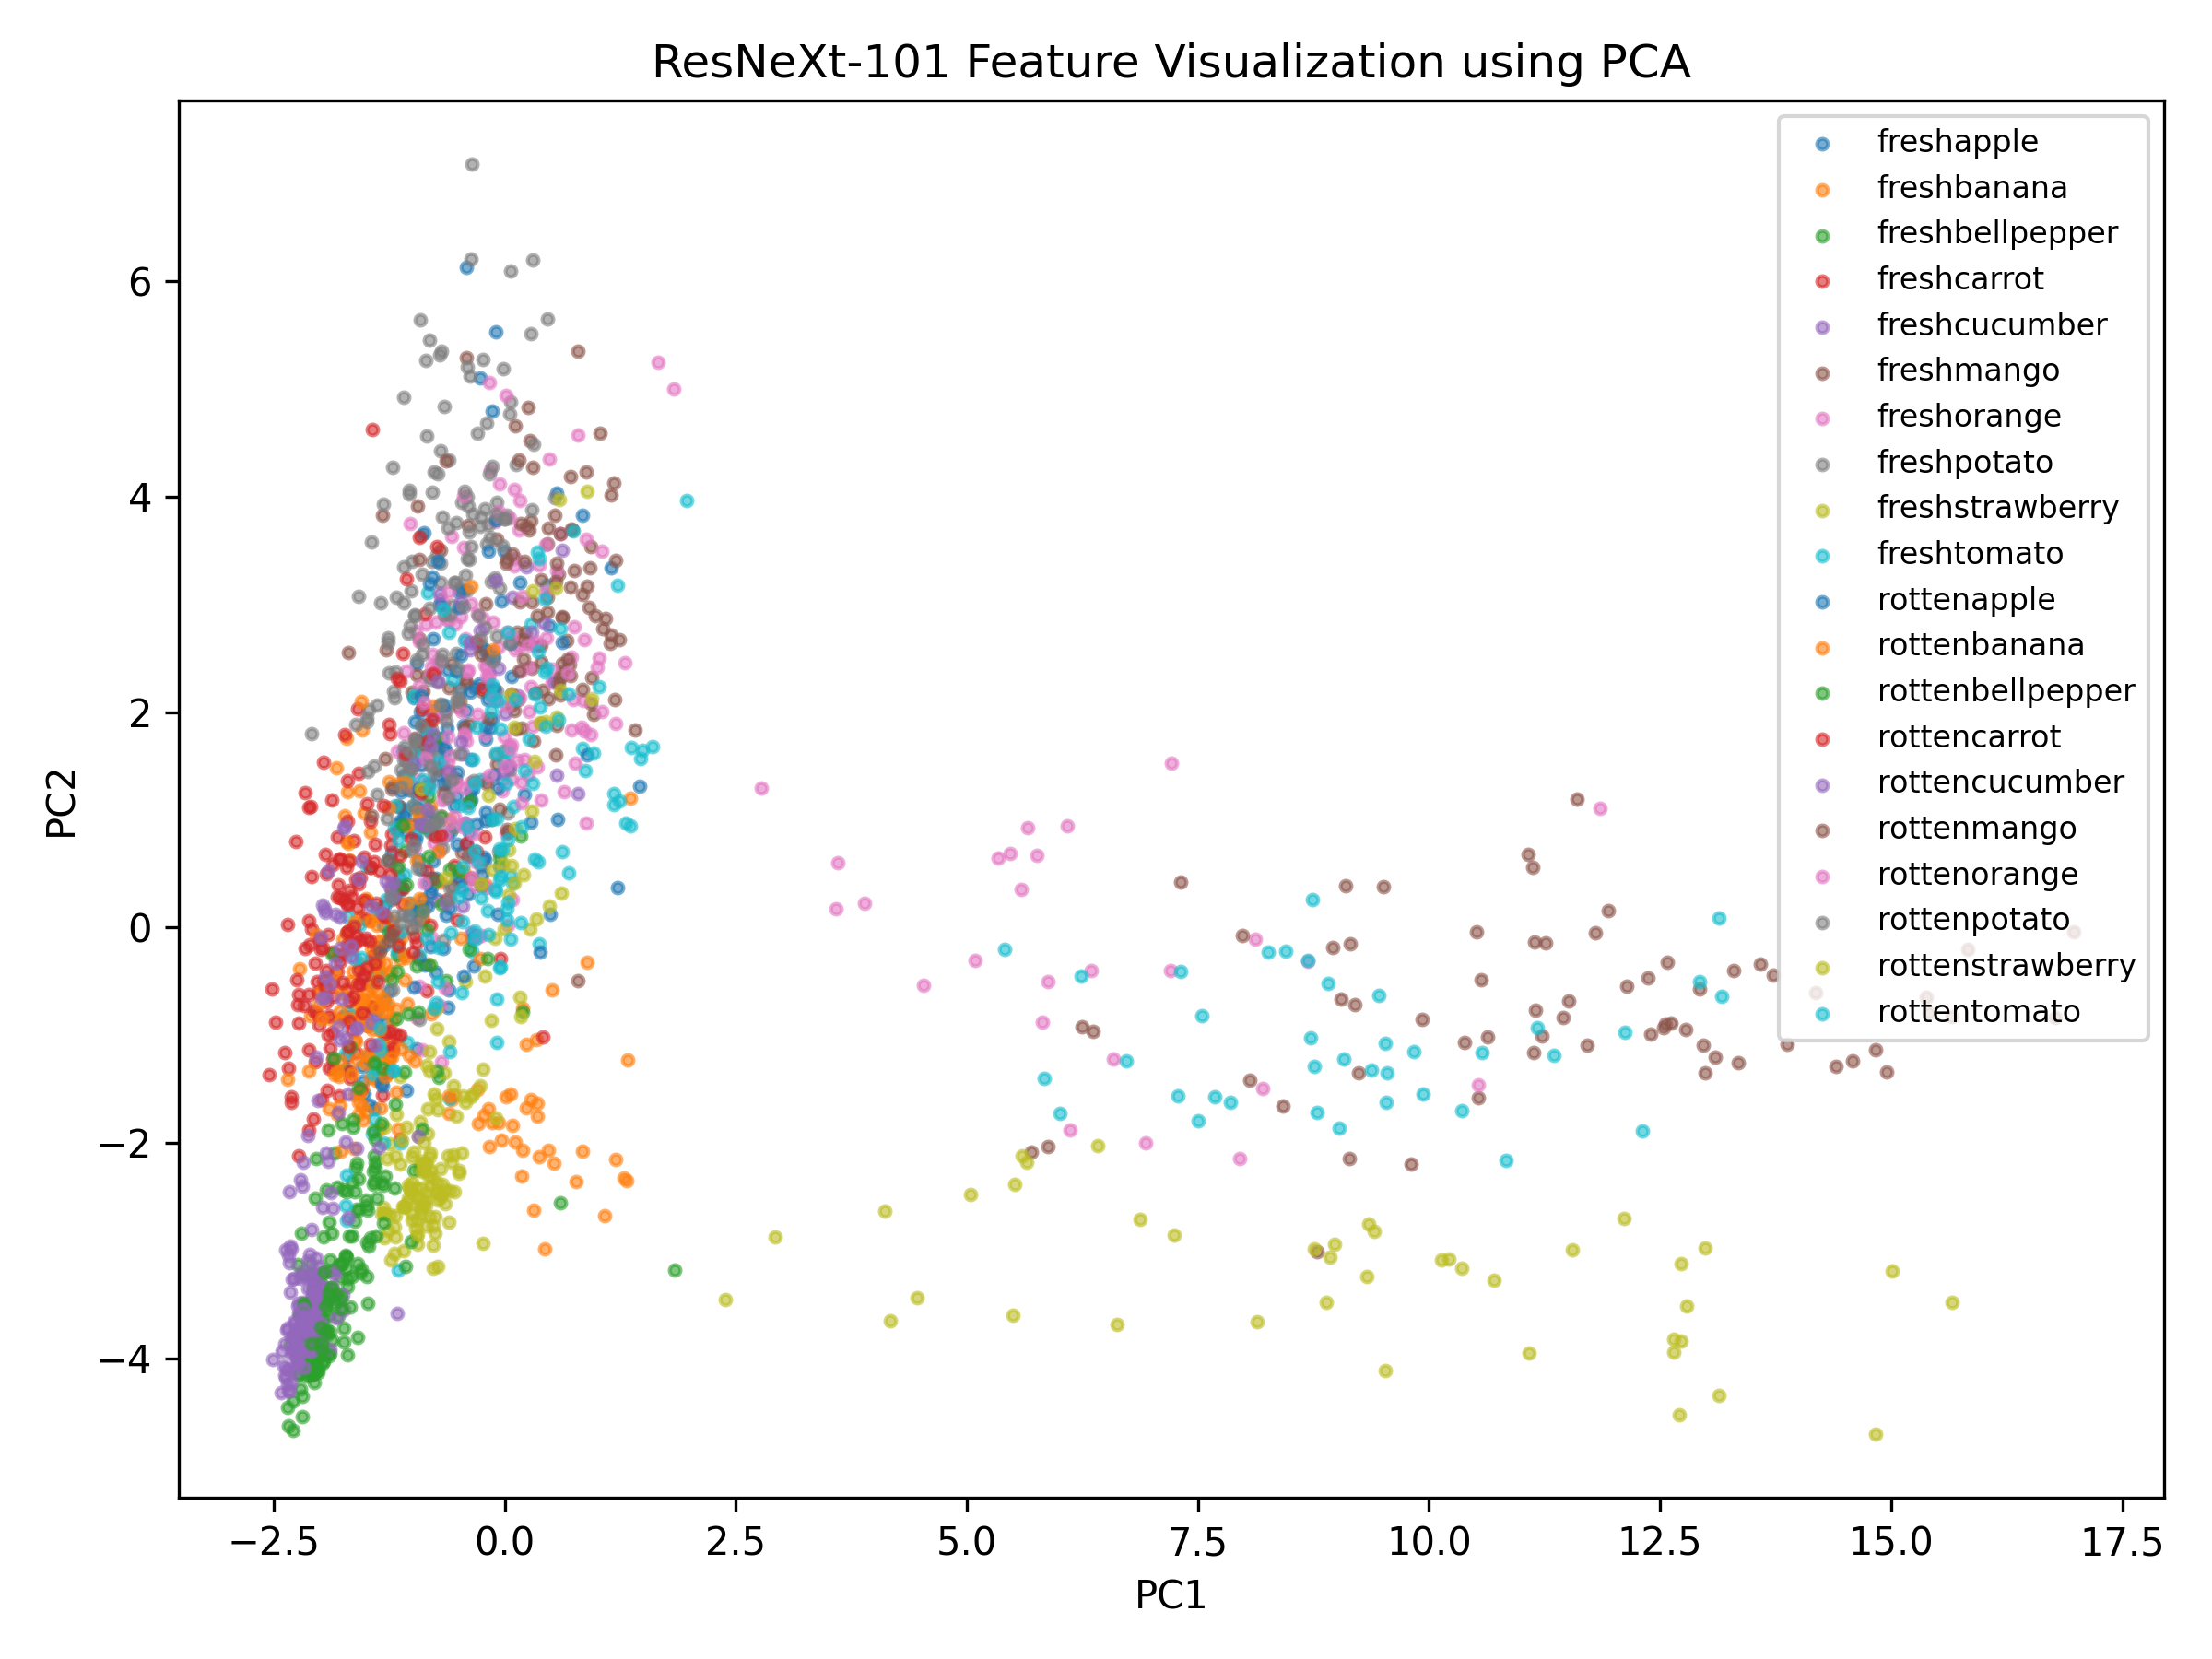

In [22]:
# Feature-space structure: are the two classes linearly separable before classification?
for name in ("resnext101_tsne_visualization.png", "resnext101_pca_visualization.png"):
    path = FIGURES / name
    if path.exists():
        display(Image(filename=str(path)))

**What the errors look like.** The residual failures are dominated by *mild* freshness — fruit
with small surface spots, local discolouration, or bruising that covers only a fraction of the
image — plus a handful of images with strong lighting variation, watermarks, or busy backgrounds.
Several are genuinely ambiguous against their own label: "fresh" and "rotten" are the ends of a
continuum that the binary label forces into a hard boundary, so a residual error rate of this
size is close to the label noise floor rather than a modelling failure.

The two error directions are *not* quite balanced: 19 rotten images were called fresh versus 12
in the opposite direction, so per-class recall is 0.9785 on rotten against 0.9869 on fresh. The
model leans slightly toward the costlier mistake for a real deployment — passing spoiled produce
as fresh. The margin is small (31 errors total), but if the pipeline were deployed, shifting the
SVM decision threshold to trade some fresh-side recall for rotten-side recall would be the
obvious adjustment.

## 12. Conclusions and limitations

**Findings.**

1. **Frozen ImageNet features are enough.** No backbone was fine-tuned; every result comes from a
   frozen feature extractor plus a classical classifier, and the pipeline still exceeds 98% test
   accuracy. This reproduces the central claim of Yuan & Chen (2024).
2. **DenseNet-201 > ResNeXt-101** under an identical protocol: 0.9783 vs 0.9528 validation
   Macro-F1, a gap of 2.6 points — despite ResNeXt-101 producing the *higher*-dimensional
   embedding (2048-d vs 1920-d). Feature quality, not feature count, is what matters.
3. **SVM is the right classifier** for these embeddings. LDA is very close and an order of
   magnitude faster; Bagging is both clearly weaker and by far the slowest, because axis-aligned
   decision trees are a poor fit for dense, correlated CNN embeddings.
4. **PCA is a runtime optimisation, not an accuracy win.** For the selected configuration it cuts
   1920 dimensions to 690 (36%) and roughly halves SVM fit time (24.9 s -> 11.1 s), but its
   effect on Macro-F1 is small and its *sign* depends on the backbone: it helped ResNeXt-101
   (+0.0033) and slightly hurt DenseNet-201 (-0.0011). The two backbones also differ in how
   compressible they are — 95% of DenseNet's variance fits in 38% of its dimensions, but
   ResNeXt-101 needs 64%, so its embedding is the less redundant of the two.
   Note that PCA hurt LDA and Bagging far more than SVM (-0.013 and -0.026 on DenseNet).
5. **Training augmentation did not help here.** The augmented DenseNet features scored *below*
   the unaugmented ones. The dataset is already clean, balanced and centred, so the augmentations
   mostly destroyed the fine-grained surface texture that the freshness signal lives in.

**Limitations.**

- The 20 original classes are collapsed to a binary target, which discards produce-type
  information and forces a hard boundary through a continuous phenomenon.
- Backbones are frozen; fine-tuning was never attempted and would likely raise the ceiling.
- Classifier hyperparameters were fixed a priori rather than tuned, so the comparison is fair
  between classifiers but none of them is at its own optimum.
- Single dataset, single source. There is no external test set, so the reported test accuracy
  measures generalisation to held-out images from the *same* distribution, not to produce
  photographed under different conditions.

### Reproducing the full study

The offline stages, in order:

```bash
python src/preprocessing/download_data.py
python src/preprocessing/check_images.py  --data-dir <dataset-path>
python src/preprocessing/make_split.py    --data-dir <dataset-path>   # -> docs/file_list.csv

python src/feature_extraction/extract_resnet18_baseline.py    --data-dir <dataset-path>
python src/feature_extraction/extract_densenet201_official.py --data-dir <dataset-path> --case no_aug
python src/feature_extraction/extract_densenet201_official.py --data-dir <dataset-path> --case aug
python src/feature_extraction/extract_resnext101.py           --data-dir <dataset-path>

python src/classification/run_pca_classifiers.py --feature-case aug --classifiers svm lda bagging
```

Complete result tables and every generated figure — including the experiments summarised but not
re-run here (end-to-end ResNet-18 training, the DenseNet+ResNeXt fusion cases, 20-class analysis)
— are in `results/tables/` and `results/figures/`.

**Reference.** Yuan, Y. & Chen, X. (2024). *Vegetable and fruit freshness detection based on deep
features and principal component analysis.* Current Research in Food Science, 8, 100656.